# Plastimatch 源码安装与使用说明

[Plastimatch](https://plastimatch.org/) 是三维医学影像处理、配准、DRR 投影和锥束 CT 重建工具集，本文档提供源码安装、输入准备、三个独立任务和结果展示。

Plastimatch 由第三方以 `Plastimatch Software License Version 1.0` 发布。本目录的 `LICENSE` 保存许可证全文；源代码、许可证、版权与归属声明及其他项目资料请以 [GitLab](https://gitlab.com/plastimatch/plastimatch) 和 [官方网站](https://plastimatch.org/) 为准。


All or portions of this licensed product (such portions are the "Software")
have been obtained under license from MGH and are subject to the terms and
conditions of the Plastimatch Software License.

See LICENSE file for the full Plastimatch Software License text.

## 1. 安装

### 1.1 MACA Docker 环境准备

可先在 MACA Docker 环境中打开一个带有 Linux/C++ 工具链的交互式容器；该容器只提供编译环境，Plastimatch 仍需在容器内从源码检出、配置、编译和安装：

```bash
docker run -it --name plastimatch-source --device=/dev/mxcd --device=/dev/dri \
  --group-add video --shm-size=8G --security-opt seccomp=unconfined \
  --ulimit memlock=-1 --ulimit stack=67108864 -v /workspace:/workspace \
  cr.metax-tech.com/public-library/maca-pytorch:3.8.0.11-torch2.6-py310-ubuntu24.04-amd64 /bin/bash
```

如果已有满足依赖的 Docker 环境，可直接进入下一步。

### 1.2 源码安装

先准备 Linux/C++ 编译环境。Debian/Ubuntu 依赖示例：

```bash
sudo apt-get update
sudo apt-get install -y build-essential cmake ninja-build git \
  libblas-dev liblapack-dev libsqlite3-dev libdcmtk-dev libdlib-dev \
  libfftw3-dev libinsighttoolkit5-dev libpng-dev libtiff-dev uuid-dev zlib1g-dev \
  python3-numpy python3-matplotlib
```

ITK 是必需依赖；DCMTK 用于 DICOM-RT；FFTW 用于 FDK ramp filter。依赖安装在非标准位置时，在下面的参数单元中设置 `ITK_DIR` 和 `DCMTK_DIR`。执行下一代码单元前，请从依赖安装完成的环境启动 Notebook。

In [1]:
from pathlib import Path
import json
import os
import subprocess

PUBLIC_PROJECT_DIR = '/workspace/MedicalImage/registration/plastimatch'
PUBLIC_WORK_DIR = PUBLIC_PROJECT_DIR + '/tutorial-run'
PROJECT_DIR = Path(os.environ.get('PLASTIMATCH_PROJECT_DIR', PUBLIC_PROJECT_DIR)).resolve()
SOURCE_DIR = Path(os.environ.get('PLASTIMATCH_SOURCE_DIR', PROJECT_DIR / '.plastimatch-source')).resolve()
BUILD_DIR = Path(os.environ.get('PLASTIMATCH_BUILD_DIR', PROJECT_DIR / '.plastimatch-build')).resolve()
INSTALL_PREFIX = Path(os.environ.get('PLASTIMATCH_INSTALL_PREFIX', PROJECT_DIR / '.plastimatch-install')).resolve()
WORK_DIR = Path(os.environ.get('PLASTIMATCH_WORK_DIR', PROJECT_DIR / 'tutorial-run')).resolve()
PUBLIC_SOURCE_DIR = PUBLIC_PROJECT_DIR + '/.plastimatch-source'
PUBLIC_BUILD_DIR = PUBLIC_PROJECT_DIR + '/.plastimatch-build'
PUBLIC_INSTALL_PREFIX = PUBLIC_PROJECT_DIR + '/.plastimatch-install'
def publicize(value):
    text = str(value)
    for actual, public in ((WORK_DIR, PUBLIC_WORK_DIR), (SOURCE_DIR, PUBLIC_SOURCE_DIR), (BUILD_DIR, PUBLIC_BUILD_DIR), (INSTALL_PREFIX, PUBLIC_INSTALL_PREFIX), (PROJECT_DIR, PUBLIC_PROJECT_DIR)):
        text = text.replace(str(actual), public)
    return text
REG_DIR = WORK_DIR / 'registration'
DRR_DIR = WORK_DIR / 'drr'
FDK_DIR = WORK_DIR / 'fdk'
PLASTIMATCH_BIN = Path(os.environ.get('PLASTIMATCH_BIN', INSTALL_PREFIX / 'bin' / 'plastimatch')).resolve()
ITK_DIR = os.environ.get('ITK_DIR', '')
DCMTK_DIR = os.environ.get('DCMTK_DIR', '')
VOLUME_SHAPE_ZYX = (64, 64, 64)
SPACING_XYZ = (2.0, 2.0, 2.0)
KNOWN_TRANSLATION_XYZ_MM = (6.0, -4.0, 2.0)
DRR_VIEWS = 120
DRR_DIM_XY = (128, 128)
SAD_MM, SID_MM = 1000.0, 1500.0
FDK_DIM_XYZ = (128, 128, 128)
FDK_VOLUME_SIZE_MM = (128.0, 128.0, 128.0)
THREADING = os.environ.get('PLASTIMATCH_THREADING', 'cpu')
GPU_ID = int(os.environ.get('PLASTIMATCH_GPU_ID', '0'))
for directory in (WORK_DIR, REG_DIR, DRR_DIR, FDK_DIR):
    directory.mkdir(parents=True, exist_ok=True)

build_env = os.environ.copy()
build_env.update({
    'PLASTIMATCH_SOURCE_DIR': str(SOURCE_DIR),
    'PLASTIMATCH_BUILD_DIR': str(BUILD_DIR),
    'PLASTIMATCH_INSTALL_PREFIX': str(INSTALL_PREFIX),
    'PLASTIMATCH_ENABLE_CUDA': os.environ.get('PLASTIMATCH_ENABLE_CUDA', 'OFF'),
})
if ITK_DIR:
    build_env['ITK_DIR'] = ITK_DIR
if DCMTK_DIR:
    build_env['DCMTK_DIR'] = DCMTK_DIR
build_script = PROJECT_DIR / 'scripts' / 'build_plastimatch.sh'
if not build_script.is_file():
    raise FileNotFoundError(f'run Notebook from the Plastimatch directory: {build_script}')
build_result = subprocess.run(
    [str(build_script)], cwd=PROJECT_DIR, env=build_env,
    text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, check=False,
)
build_tail = '\n'.join(build_result.stdout.splitlines()[-40:])
print(publicize(build_tail))
build_result.check_returncode()
print(publicize(json.dumps({
    'source': str(SOURCE_DIR), 'build': str(BUILD_DIR),
    'install_prefix': str(INSTALL_PREFIX), 'plastimatch': str(PLASTIMATCH_BIN),
}, indent=2)))

-- Up-to-date: /workspace/MedicalImage/registration/plastimatch/.plastimatch-install/include/plastimatch/plm_int.h
-- Up-to-date: /workspace/MedicalImage/registration/plastimatch/.plastimatch-install/include/plastimatch/plm_macros.h
-- Up-to-date: /workspace/MedicalImage/registration/plastimatch/.plastimatch-install/include/plastimatch/plm_math.h
-- Up-to-date: /workspace/MedicalImage/registration/plastimatch/.plastimatch-install/include/plastimatch/plm_return_code.h
-- Up-to-date: /workspace/MedicalImage/registration/plastimatch/.plastimatch-install/include/plastimatch/plm_sleep.h
-- Up-to-date: /workspace/MedicalImage/registration/plastimatch/.plastimatch-install/include/plastimatch/plm_timer.h
-- Up-to-date: /workspace/MedicalImage/registration/plastimatch/.plastimatch-install/include/plastimatch/plm_timer_p.h
-- Up-to-date: /workspace/MedicalImage/registration/plastimatch/.plastimatch-install/include/plastimatch/plm_va_copy.h
-- Up-to-date: /workspace/MedicalImage/registration/plas

## 2. 生成输入

以下代码与三个任务共用同一组路径、spacing、origin 和坐标轴约定。

fixed: /workspace/MedicalImage/registration/plastimatch/tutorial-run/fixed.mha (64, 64, 64)
moving: /workspace/MedicalImage/registration/plastimatch/tutorial-run/moving.mha (64, 64, 64)


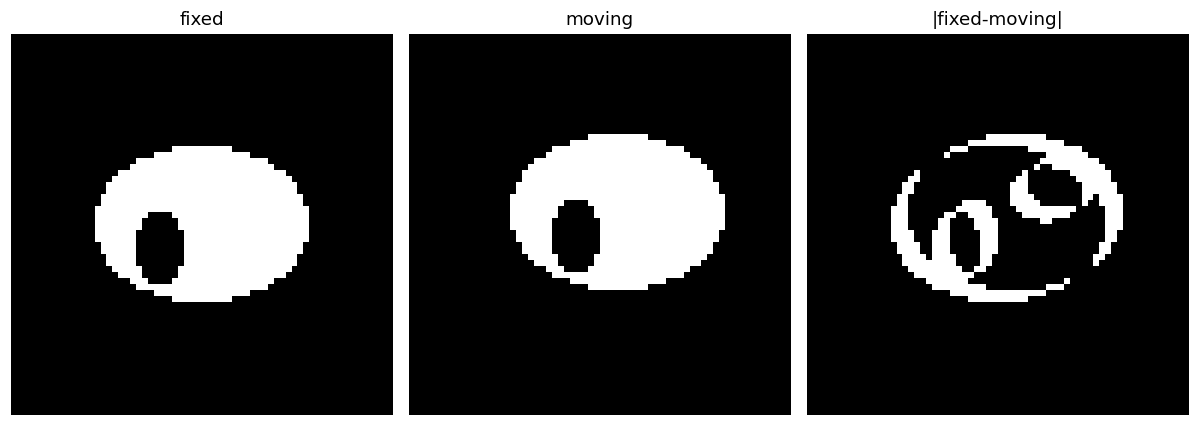

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def write_mha(path, array_zyx, spacing_xyz):
    array_zyx = np.ascontiguousarray(array_zyx, dtype='<f4')
    zdim, ydim, xdim = array_zyx.shape
    origin_xyz = tuple(-0.5 * (dim - 1) * step for dim, step in zip((xdim, ydim, zdim), spacing_xyz))
    header = '\n'.join([
        'ObjectType = Image', 'NDims = 3', 'BinaryData = True',
        'BinaryDataByteOrderMSB = False', 'CompressedData = False',
        'TransformMatrix = 1 0 0 0 1 0 0 0 1',
        f'Offset = {origin_xyz[0]} {origin_xyz[1]} {origin_xyz[2]}',
        f'ElementSpacing = {spacing_xyz[0]} {spacing_xyz[1]} {spacing_xyz[2]}',
        f'DimSize = {xdim} {ydim} {zdim}', 'AnatomicalOrientation = RAI',
        'ElementType = MET_FLOAT', 'ElementDataFile = LOCAL', '',
    ]).encode('ascii')
    path.write_bytes(header + array_zyx.tobytes())

z, y, x = np.indices(VOLUME_SHAPE_ZYX, dtype=np.float32)
cx, cy, cz = (np.asarray(VOLUME_SHAPE_ZYX[::-1], dtype=np.float32) - 1) / 2
ellipsoid = (((x - cx) / 18.0) ** 2 + ((y - cy) / 13.0) ** 2 + ((z - cz) / 20.0) ** 2) < 1.0
shell = (((x - (cx + 8)) / 7.0) ** 2 + ((y - (cy - 5)) / 5.0) ** 2 + ((z - (cz + 4)) / 9.0) ** 2) < 1.0
cavity = (((x - (cx - 7)) / 4.0) ** 2 + ((y - (cy + 4)) / 6.0) ** 2 + ((z - cz) / 5.0) ** 2) < 1.0
fixed = (20.0 * ellipsoid + 120.0 * shell - 55.0 * cavity + 35.0 * (((x - (cx + 13)) ** 2 + (y - (cy - 10)) ** 2 + (z - (cz - 8)) ** 2) < 3.0)).astype(np.float32)
shift_voxels = np.rint(np.asarray(KNOWN_TRANSLATION_XYZ_MM) / np.asarray(SPACING_XYZ)).astype(int)
moving = np.roll(fixed, shift=tuple(shift_voxels[::-1]), axis=(0, 1, 2))
write_mha(WORK_DIR / 'fixed.mha', fixed, SPACING_XYZ)
write_mha(WORK_DIR / 'moving.mha', moving, SPACING_XYZ)
slice_z = VOLUME_SHAPE_ZYX[0] // 2
limits = np.percentile(np.concatenate([fixed.ravel(), moving.ravel()]), (1, 99))
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for axis, image, title in zip(axes, (fixed[slice_z], moving[slice_z], np.abs(fixed[slice_z] - moving[slice_z])), ('fixed', 'moving', '|fixed-moving|')):
    axis.imshow(image, cmap='gray', vmin=limits[0], vmax=limits[1])
    axis.set_title(title); axis.axis('off')
plt.tight_layout(); plt.show()
print('fixed:', publicize(WORK_DIR / 'fixed.mha'), fixed.shape)
print('moving:', publicize(WORK_DIR / 'moving.mha'), moving.shape)

## 3. rigid + B-spline 配准

$ /workspace/MedicalImage/registration/plastimatch/.plastimatch-install/bin/plastimatch register /workspace/MedicalImage/registration/plastimatch/tutorial-run/registration/register.txt
{
  "task": "registration",
  "warped": "/workspace/MedicalImage/registration/plastimatch/tutorial-run/registration/warped.mha",
  "transform": "/workspace/MedicalImage/registration/plastimatch/tutorial-run/registration/transform.txt",
  "log": "/workspace/MedicalImage/registration/plastimatch/tutorial-run/registration/register.log"
}

registration result: /workspace/MedicalImage/registration/plastimatch/tutorial-run/registration/warped.mha (64, 64, 64)
registration MSE before/after: 87.78038024902344 0.006141202058643103


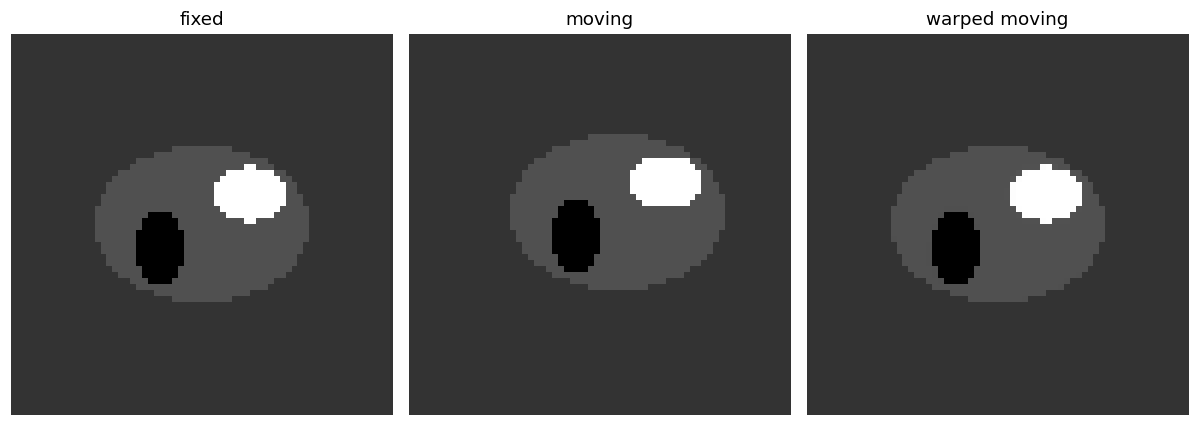

In [3]:
registration_script = PROJECT_DIR / 'scripts' / 'run_registration.py'
registration_result = subprocess.run([
    'python3', str(registration_script),
    '--fixed', str(WORK_DIR / 'fixed.mha'),
    '--moving', str(WORK_DIR / 'moving.mha'),
    '--output-dir', str(REG_DIR),
    '--threading', THREADING, '--gpuid', str(GPU_ID),
    '--plastimatch', str(PLASTIMATCH_BIN),
], cwd=PROJECT_DIR, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, check=False)
print(publicize(registration_result.stdout))
registration_result.check_returncode()
def read_mha(path):
    raw = path.read_bytes(); marker = b'ElementDataFile = LOCAL\n'
    header, payload = raw.split(marker, 1); fields = {}
    for line in header.decode('ascii').splitlines():
        if '=' in line:
            key, value = line.split('=', 1); fields[key.strip()] = value.strip()
    dims_xyz = tuple(map(int, fields['DimSize'].split()))
    return fields, np.frombuffer(payload, dtype='<f4').copy().reshape(tuple(reversed(dims_xyz)))
warped_fields, warped = read_mha(REG_DIR / 'warped.mha')
print('registration result:', publicize(REG_DIR / 'warped.mha'), warped.shape)
print('registration MSE before/after:', float(np.mean((fixed - moving) ** 2)), float(np.mean((fixed - warped) ** 2)))
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for axis, image, title in zip(axes, (fixed[slice_z], moving[slice_z], warped[slice_z]), ('fixed', 'moving', 'warped moving')):
    low, high = np.percentile(image, (1, 99)); axis.imshow(image, cmap='gray', vmin=low, vmax=max(high, low + 1)); axis.set_title(title); axis.axis('off')
plt.tight_layout(); plt.show()

## 4. DRR 投影

$ /workspace/MedicalImage/registration/plastimatch/.plastimatch-install/bin/plastimatch drr --threading cpu --output-format pfm --num-angles 120 --gantry-angle-spacing 3.0 --sad 1000.0 --sid 1500.0 --dim 128 128 --detector-size 160.0 160.0 --input /workspace/MedicalImage/registration/plastimatch/tutorial-run/fixed.mha --output /workspace/MedicalImage/registration/plastimatch/tutorial-run/drr/proj_
{
  "task": "drr",
  "projections": 120,
  "output_dir": "/workspace/MedicalImage/registration/plastimatch/tutorial-run/drr",
  "log": "/workspace/MedicalImage/registration/plastimatch/tutorial-run/drr/drr.log"
}

DRR result: /workspace/MedicalImage/registration/plastimatch/tutorial-run/drr 120 PFM + 120 geometry files
first DRR: /workspace/MedicalImage/registration/plastimatch/tutorial-run/drr/proj_0000.pfm (128, 128) scale: -1.0


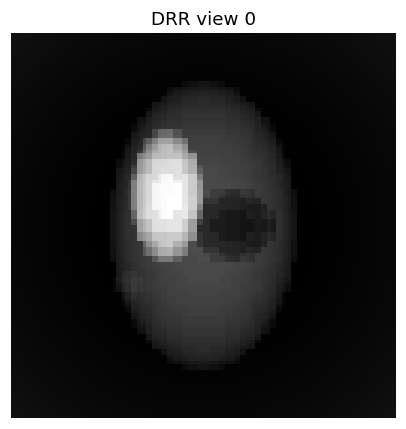

In [4]:
drr_script = PROJECT_DIR / 'scripts' / 'run_drr.py'
drr_result = subprocess.run([
    'python3', str(drr_script),
    '--input', str(WORK_DIR / 'fixed.mha'),
    '--output-dir', str(DRR_DIR),
    '--num-angles', str(DRR_VIEWS),
    '--angle-spacing', '3', '--sad', str(SAD_MM), '--sid', str(SID_MM),
    '--dim', str(DRR_DIM_XY[0]), str(DRR_DIM_XY[1]),
    '--threading', THREADING,
    '--plastimatch', str(PLASTIMATCH_BIN),
], cwd=PROJECT_DIR, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, check=False)
print(publicize(drr_result.stdout))
drr_result.check_returncode()
pfm_paths = sorted(DRR_DIR.glob('proj_*.pfm'))
geometry_paths = sorted(DRR_DIR.glob('proj_*.txt'))
if len(pfm_paths) != DRR_VIEWS or len(geometry_paths) != DRR_VIEWS:
    raise RuntimeError(f'expected {DRR_VIEWS} PFM/TXT pairs, got {len(pfm_paths)}/{len(geometry_paths)}')
first_drr = pfm_paths[0]
def read_pfm(path):
    with path.open('rb') as handle:
        magic = handle.readline().strip()
        if magic != b'Pf':
            raise ValueError(f'unsupported PFM header: {magic!r}')
        width, height = map(int, handle.readline().split())
        scale = float(handle.readline())
        values = np.fromfile(handle, dtype='<f4', count=width * height)
    return values.reshape((height, width)), scale
drr_image, drr_scale = read_pfm(first_drr)
print('DRR result:', publicize(DRR_DIR), f'{len(pfm_paths)} PFM + {len(geometry_paths)} geometry files')
print('first DRR:', publicize(first_drr), drr_image.shape, 'scale:', drr_scale)
plt.figure(figsize=(5, 4)); plt.imshow(drr_image, cmap='gray'); plt.title('DRR view 0'); plt.axis('off'); plt.tight_layout(); plt.show()

## 5. FDK 锥束 CT 重建

$ /workspace/MedicalImage/registration/plastimatch/.plastimatch-install/bin/plastimatch fdk --threading cpu --filter ramp --image-range 0 119 --dim 128 128 128 --volume-size 128.0 128.0 128.0 --input /workspace/MedicalImage/registration/plastimatch/tutorial-run/drr --output /workspace/MedicalImage/registration/plastimatch/tutorial-run/fdk/reconstruction.mha
{
  "task": "fdk",
  "reconstruction": "/workspace/MedicalImage/registration/plastimatch/tutorial-run/fdk/reconstruction.mha",
  "input_projections": 120,
  "log": "/workspace/MedicalImage/registration/plastimatch/tutorial-run/fdk/fdk.log"
}

FDK result: /workspace/MedicalImage/registration/plastimatch/tutorial-run/fdk/reconstruction.mha (128, 128, 128)


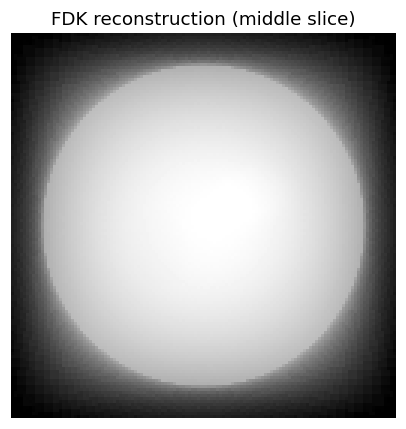

In [5]:
fdk_script = PROJECT_DIR / 'scripts' / 'run_fdk.py'
fdk_result = subprocess.run([
    'python3', str(fdk_script),
    '--input-dir', str(DRR_DIR),
    '--output', str(FDK_DIR / 'reconstruction.mha'),
    '--image-range', '0', str(DRR_VIEWS - 1),
    '--dim', *map(str, FDK_DIM_XYZ),
    '--volume-size', *map(str, FDK_VOLUME_SIZE_MM),
    '--threading', THREADING,
    '--plastimatch', str(PLASTIMATCH_BIN),
], cwd=PROJECT_DIR, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, check=False)
print(publicize(fdk_result.stdout))
fdk_result.check_returncode()
recon_fields, reconstruction = read_mha(FDK_DIR / 'reconstruction.mha')
middle_slice = reconstruction[reconstruction.shape[0] // 2]
print('FDK result:', publicize(FDK_DIR / 'reconstruction.mha'), reconstruction.shape)
low, high = np.percentile(middle_slice, (1, 99))
plt.figure(figsize=(5, 4)); plt.imshow(middle_slice, cmap='gray', vmin=low, vmax=max(high, low + 1)); plt.title('FDK reconstruction (middle slice)'); plt.axis('off'); plt.tight_layout(); plt.show()

In [6]:
assert (REG_DIR / 'warped.mha').is_file()
assert len(list(DRR_DIR.glob('proj_*.pfm'))) == DRR_VIEWS
assert len(list(DRR_DIR.glob('proj_*.txt'))) == DRR_VIEWS
assert (FDK_DIR / 'reconstruction.mha').is_file()

---
本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以其官方网站或原始发布页面为准。

Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.